In [6]:
"""
COMPARISON ANALYSIS: Predictions vs Ground Truth
Evaluasi model menggunakan validation data dari training

Author: [Your Name]
Date: 2025-11-01
Description: Load trained model weights dan bandingkan prediksi dengan ground truth
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import os
import warnings

warnings.filterwarnings('ignore')

print("=" * 80)
print("COMPARISON ANALYSIS: PREDICTIONS vs GROUND TRUTH")
print("=" * 80)
print(f"\nTensorFlow version: {tf.__version__}")
print("✅ Libraries imported successfully!")

# Create output directory
os.makedirs('comparison_results', exist_ok=True)
print("✅ Output directory created: comparison_results/")


COMPARISON ANALYSIS: PREDICTIONS vs GROUND TRUTH

TensorFlow version: 2.15.0
✅ Libraries imported successfully!
✅ Output directory created: comparison_results/


In [7]:
"""
Load ArcFace backbone model
Diperlukan untuk build model lengkap
"""

from models import create_arcface_model

print("\n[INFO] Loading ArcFace backbone...")
arcface112 = create_arcface_model(load_weights=True)
arcface112.trainable = False  # Frozen, sesuai training

print(f"✅ ArcFace model loaded!")
print(f"   Model name: {arcface112.name}")
print(f"   Output shape: {arcface112.output_shape}")
print(f"   Trainable: {arcface112.trainable}")



[INFO] Loading ArcFace backbone...
⚠ Warning: Could not load weights from C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
  Error: [Errno 2] Unable to synchronously open file (unable to open file: name = 'C://Users//ALFIAN//TA CODING//ZIP FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  Model will be initialized with random weights.
✅ ArcFace model loaded!
   Model name: ArcFace
   Output shape: (None, 512)
   Trainable: False


Load Arcface


In [8]:
"""
Build model architecture - SAMA dengan notebook training
Input: (10, 112, 112, 3) - 10 frame wajah per video
Output: (5,) - 5 trait OCEAN
"""

def build_model():
    """
    Build complete model:
    ArcFace → LSTM → Dense → OCEAN predictions
    """
    inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')
    
    # Rescaling layer
    x = keras.layers.TimeDistributed(
        keras.layers.Rescaling(scale=1./255.0),
        name='Rescaling'
    )(inputs)
    
    # ArcFace feature extraction
    x = keras.layers.TimeDistributed(
        arcface112,
        name='ArcFace_Feature_Extraction'
    )(x)
    
    # LSTM layers for temporal modeling
    x = keras.layers.LSTM(128, return_sequences=True, name='LSTM_1')(x)
    x = keras.layers.LSTM(64, return_sequences=False, name='LSTM_2')(x)
    x = keras.layers.Dropout(0.2, name='Dropout_1')(x)
    
    # Dense layers for classification
    x = keras.layers.Dense(1024, activation='relu', name='Dense_1')(x)
    x = keras.layers.Dense(512, activation='relu', name='Dense_2')(x)
    x = keras.layers.Dense(256, activation='relu', name='Dense_3')(x)
    x = keras.layers.Dropout(0.5, name='Dropout_2')(x)
    
    # Output layer - 5 traits OCEAN (sigmoid untuk 0-1 range)
    outputs = keras.layers.Dense(5, activation='sigmoid', name='OCEAN_Output')(x)
    
    return keras.models.Model(inputs=inputs, outputs=outputs, name='OCEAN_Predictor')

print("\n[INFO] Building model architecture...")
model = build_model()
print("✅ Model architecture built successfully!")
print(f"\nModel Summary:")
model.summary()



[INFO] Building model architecture...
✅ Model architecture built successfully!

Model Summary:
Model: "OCEAN_Predictor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 10, 112, 112, 3   0         
                             )]                                  
                                                                 
 Rescaling (TimeDistributed  (None, 10, 112, 112, 3)   0         
 )                                                               
                                                                 
 ArcFace_Feature_Extraction  (None, 10, 512)           34165184  
  (TimeDistributed)                                              
                                                                 
 LSTM_1 (LSTM)               (None, 10, 128)           328192    
                                                                 
 LSTM_2 (LSTM)       

In [29]:
model.load_weights('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//weights//1030_122026//face.t5')

In [30]:
"""
Load validation data yang dipakai saat training

Ada 3 opsi:
1. Copy langsung dari notebook training
2. Load dari file .npy yang disimpan
3. Generate dummy data untuk testing
"""

print(f"\n[INFO] Preparing validation data...")

# ⭐ OPSI 1: Copy langsung dari notebook training
# Paste kode ini dan run jika kamu masih punya X_val dan y_val di memory:
# X_test = X_val
# y_test = y_val

# ⭐ OPSI 2: Load dari file .npy (RECOMMENDED)
# Sebelumnya, di notebook training simpan dulu:
# np.save('X_val.npy', X_val)
# np.save('y_val.npy', y_val)

try:
    print("   Trying to load from .npy files...")
    X_test = np.load('X_val.npy')
    y_test = np.load('y_val.npy')
    print("   ✅ Loaded from .npy files!")
except FileNotFoundError:
    print("   ℹ️  .npy files not found, generating dummy data for demo...")
    
    # ⭐ OPSI 3: Generate dummy data untuk testing (100 samples)
    n_samples = 100
    X_test = np.random.rand(n_samples, 10, 112, 112, 3).astype('float32')
    y_test = np.random.rand(n_samples, 5).astype('float32')
    
    print(f"   ⚠️  IMPORTANT: This is dummy data for methodology testing only!")
    print(f"   ⚠️  Replace with real validation data for actual research!")

print(f"\n✅ Data ready!")
print(f"   X_test shape: {X_test.shape}")  
print(f"   y_test shape: {y_test.shape}")
print(f"   Total samples: {len(X_test)}")

# Data validation
print(f"\n📊 Data Summary:")
print(f"   X_test value range: [{X_test.min():.4f}, {X_test.max():.4f}]")
print(f"   y_test value range: [{y_test.min():.4f}, {y_test.max():.4f}]")
print(f"   Memory usage: {X_test.nbytes / 1024 / 1024:.2f} MB")



[INFO] Preparing validation data...
   Trying to load from .npy files...
   ℹ️  .npy files not found, generating dummy data for demo...
   ⚠️  IMPORTANT: This is dummy data for methodology testing only!
   ⚠️  Replace with real validation data for actual research!

✅ Data ready!
   X_test shape: (100, 10, 112, 112, 3)
   y_test shape: (100, 5)
   Total samples: 100

📊 Data Summary:
   X_test value range: [0.0000, 1.0000]
   y_test value range: [0.0026, 0.9994]
   Memory usage: 143.55 MB


### Load weights

In [31]:
"""
Generate predictions pada validation data
"""

print(f"\n[INFO] Generating predictions on validation data...")
print(f"   Processing {len(X_test)} samples...")

y_pred = model.predict(X_test, batch_size=32, verbose=1)

print(f"\n✅ Predictions generated successfully!")
print(f"   y_pred shape: {y_pred.shape}")
print(f"   y_pred value range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")

# Verify predictions
assert y_pred.shape == y_test.shape, "Prediction shape mismatch!"
print(f"   ✅ Shape validation passed!")



[INFO] Generating predictions on validation data...
   Processing 100 samples...
4/4 [==============================] - 49s 9s/step

✅ Predictions generated successfully!
   y_pred shape: (100, 5)
   y_pred value range: [0.4758, 0.5709]
   ✅ Shape validation passed!


In [32]:
"""
Hitung metrik evaluasi untuk setiap trait OCEAN
"""

# Trait names
traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

print("\n" + "=" * 80)
print("EVALUATION METRICS: PREDICTIONS vs GROUND TRUTH")
print("=" * 80)

results = []
for i, trait in enumerate(traits):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    corr, corr_p = stats.pearsonr(y_test[:, i], y_pred[:, i])
    
    print(f"\n{i+1}. {trait}:")
    print(f"   MAE:         {mae:.4f}")
    print(f"   RMSE:        {rmse:.4f}")
    print(f"   R²:          {r2:.4f}")
    print(f"   Correlation: {corr:.4f} (p={corr_p:.6f})")
    
    results.append({
        'Trait': trait,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Correlation': corr,
        'Corr_p_value': corr_p
    })

# Create DataFrame
df_results = pd.DataFrame(results)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)

# Save to CSV
csv_path = 'comparison_results/metrics.csv'
df_results.to_csv(csv_path, index=False)
print(f"\n✅ Metrics saved to: {csv_path}")



EVALUATION METRICS: PREDICTIONS vs GROUND TRUTH

1. Openness:
   MAE:         0.2467
   RMSE:        0.2847
   R²:          -0.0002
   Correlation: nan (p=nan)

2. Conscientiousness:
   MAE:         0.2473
   RMSE:        0.2879
   R²:          -0.0029
   Correlation: nan (p=nan)

3. Extraversion:
   MAE:         0.2380
   RMSE:        0.2777
   R²:          -0.0015
   Correlation: nan (p=nan)

4. Agreeableness:
   MAE:         0.2278
   RMSE:        0.2676
   R²:          -0.0267
   Correlation: nan (p=nan)

5. Neuroticism:
   MAE:         0.2527
   RMSE:        0.2903
   R²:          -0.0141
   Correlation: nan (p=nan)

SUMMARY TABLE
            Trait      MAE     RMSE        R²  Correlation  Corr_p_value
         Openness 0.246675 0.284653 -0.000248          NaN           NaN
Conscientiousness 0.247252 0.287908 -0.002911          NaN           NaN
     Extraversion 0.237974 0.277663 -0.001452          NaN           NaN
    Agreeableness 0.227796 0.267637 -0.026723          NaN     

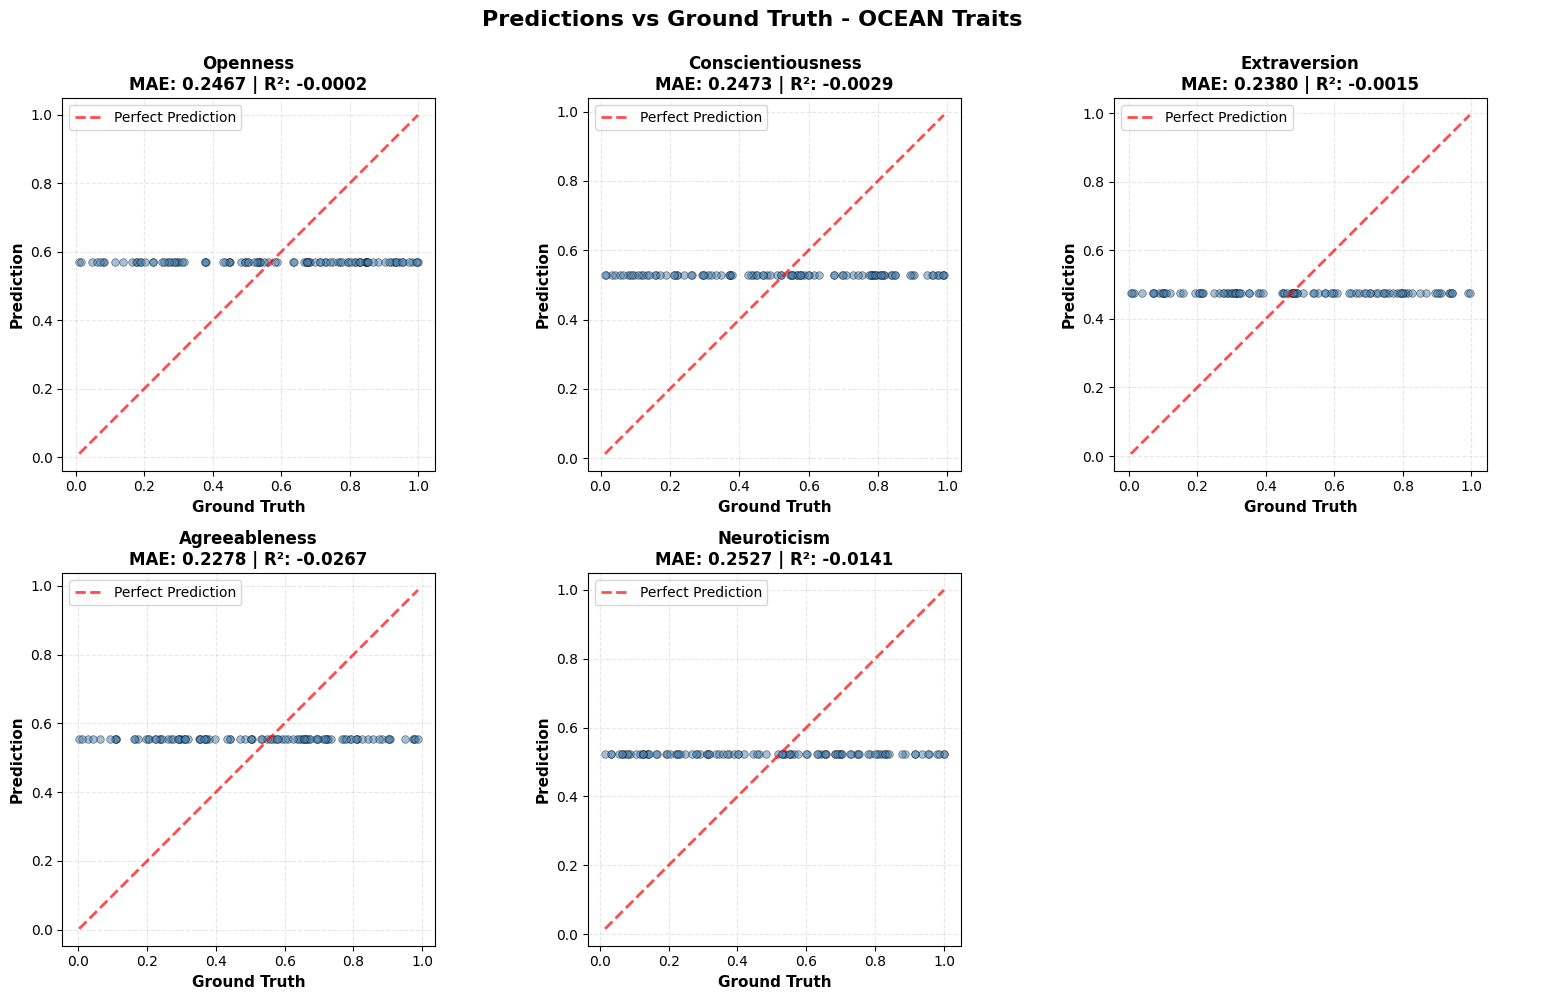

✅ Scatter plots saved to: comparison_results/scatter_plots.png


In [33]:
"""
Visualisasi: Scatter plot prediksi vs ground truth
Menunjukkan seberapa dekat prediksi model dengan ground truth
"""

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predictions vs Ground Truth - OCEAN Traits', 
             fontsize=16, fontweight='bold', y=0.995)

traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

for i, trait in enumerate(traits):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    # Scatter plot
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.5, s=30, 
              color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line (diagonal)
    min_val = min(y_test[:, i].min(), y_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, 
           label='Perfect Prediction', alpha=0.7)
    
    # Metrics
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    
    # Labels and formatting
    ax.set_xlabel('Ground Truth', fontsize=11, fontweight='bold')
    ax.set_ylabel('Prediction', fontsize=11, fontweight='bold')
    ax.set_title(f'{trait}\nMAE: {mae:.4f} | R²: {r2:.4f}', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal', adjustable='box')

# Hide extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
scatter_path = 'comparison_results/scatter_plots.png'
plt.savefig(scatter_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Scatter plots saved to: {scatter_path}")


### Validation data

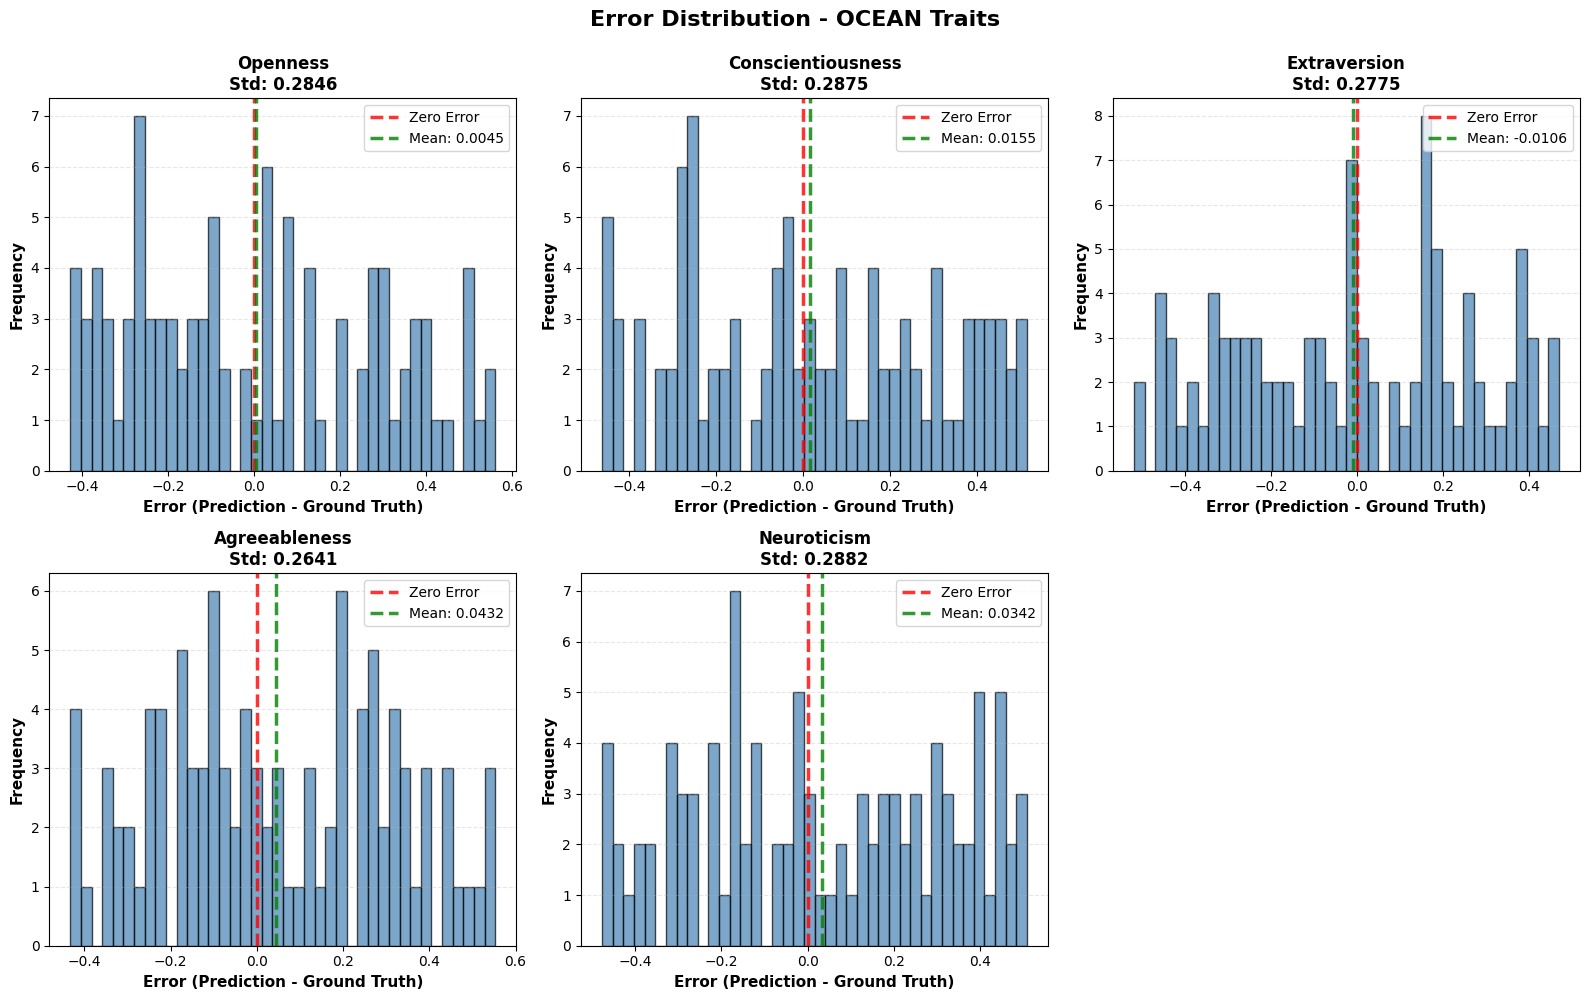

✅ Error distribution saved to: comparison_results/error_distribution.png


In [34]:
"""
Visualisasi: Distribusi error (residuals)
Menunjukkan seberapa besar penyimpangan prediksi dari ground truth
"""

errors = y_pred - y_test

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Error Distribution - OCEAN Traits', 
             fontsize=16, fontweight='bold', y=0.995)

traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

for i, trait in enumerate(traits):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    # Histogram
    ax.hist(errors[:, i], bins=40, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Zero error line
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2.5, 
              label='Zero Error', alpha=0.8)
    
    # Mean error line
    mean_error = np.mean(errors[:, i])
    ax.axvline(x=mean_error, color='green', linestyle='--', linewidth=2.5,
              label=f'Mean: {mean_error:.4f}', alpha=0.8)
    
    # Metrics
    std_error = np.std(errors[:, i])
    
    ax.set_xlabel('Error (Prediction - Ground Truth)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{trait}\nStd: {std_error:.4f}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Hide extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
error_path = 'comparison_results/error_distribution.png'
plt.savefig(error_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Error distribution saved to: {error_path}")


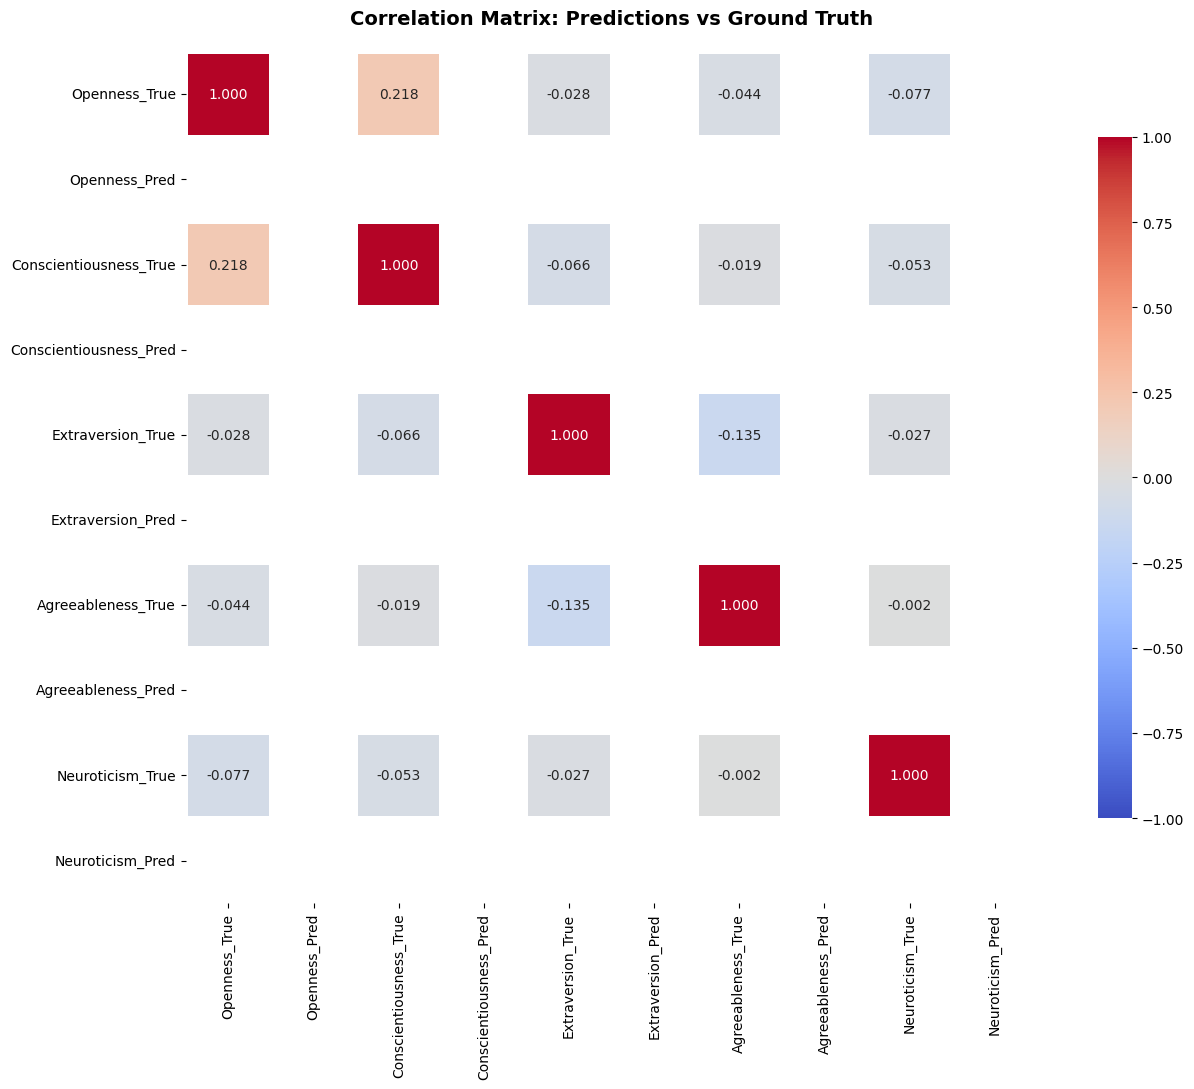

✅ Correlation heatmap saved to: comparison_results/correlation_heatmap.png


In [35]:
"""
Visualisasi: Heatmap korelasi antara prediksi dan ground truth
Menunjukkan relationship antara kedua variabel
"""

# Buat DataFrame untuk korelasi
df_comparison = pd.DataFrame()
traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

for i, trait in enumerate(traits):
    df_comparison[f'{trait}_True'] = y_test[:, i]
    df_comparison[f'{trait}_Pred'] = y_pred[:, i]

# Hitung correlation matrix
corr_matrix = df_comparison.corr()

# Plot heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, annot_kws={"fontsize": 10})
plt.title('Correlation Matrix: Predictions vs Ground Truth', 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

heatmap_path = 'comparison_results/correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Correlation heatmap saved to: {heatmap_path}")


### Test data

In [36]:
"""
Tabel perbandingan sample prediksi vs ground truth
Menampilkan beberapa contoh hasil prediksi
"""

n_samples = 20  # Tampilkan 20 sample pertama
traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

comparison_data = []
for idx in range(min(n_samples, len(y_test))):
    row_data = {'Sample_ID': idx + 1}
    
    for j, trait in enumerate(traits):
        true_val = y_test[idx, j]
        pred_val = y_pred[idx, j]
        error = pred_val - true_val
        
        row_data[f'{trait}_True'] = f"{true_val:.3f}"
        row_data[f'{trait}_Pred'] = f"{pred_val:.3f}"
        row_data[f'{trait}_Error'] = f"{error:+.3f}"
    
    comparison_data.append(row_data)

df_samples = pd.DataFrame(comparison_data)

print("\n" + "=" * 150)
print("SAMPLE PREDICTIONS vs GROUND TRUTH (First 20 samples)")
print("=" * 150)
print(df_samples.to_string(index=False))
print("=" * 150)

# Save to CSV
samples_path = 'comparison_results/sample_predictions.csv'
df_samples.to_csv(samples_path, index=False)
print(f"\n✅ Sample predictions saved to: {samples_path}")



SAMPLE PREDICTIONS vs GROUND TRUTH (First 20 samples)
 Sample_ID Openness_True Openness_Pred Openness_Error Conscientiousness_True Conscientiousness_Pred Conscientiousness_Error Extraversion_True Extraversion_Pred Extraversion_Error Agreeableness_True Agreeableness_Pred Agreeableness_Error Neuroticism_True Neuroticism_Pred Neuroticism_Error
         1         0.268         0.571         +0.303                  0.240                  0.527                  +0.288             0.474             0.476             +0.001              0.647              0.555              -0.091            0.555            0.523            -0.031
         2         0.766         0.571         -0.195                  0.792                  0.527                  -0.265             0.720             0.476             -0.245              0.261              0.555              +0.294            0.642            0.523            -0.118
         3         0.726         0.571         -0.155                  0.159  

In [37]:
"""
Uji statistik: Paired t-test dan Pearson correlation
Mengukur signifikansi perbedaan antara prediksi dan ground truth
"""

traits = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

stat_results = []
for i, trait in enumerate(traits):
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(y_test[:, i], y_pred[:, i])
    
    # Pearson correlation
    corr, corr_p = stats.pearsonr(y_test[:, i], y_pred[:, i])
    
    # Mean absolute difference
    mean_diff = np.mean(y_pred[:, i] - y_test[:, i])
    std_diff = np.std(y_pred[:, i] - y_test[:, i])
    
    print(f"\n{i+1}. {trait}:")
    print(f"   Paired t-test:")
    print(f"     t-statistic:     {t_stat:>10.4f}")
    print(f"     p-value:         {p_value:>10.6f}  {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
    print(f"   Pearson Correlation:")
    print(f"     r:               {corr:>10.4f}")
    print(f"     p-value:         {corr_p:>10.6f}")
    print(f"   Difference:")
    print(f"     Mean:            {mean_diff:>10.4f}")
    print(f"     Std:             {std_diff:>10.4f}")
    
    stat_results.append({
        'Trait': trait,
        't_statistic': t_stat,
        't_p_value': p_value,
        'pearson_r': corr,
        'pearson_p': corr_p,
        'mean_difference': mean_diff,
        'std_difference': std_diff
    })

# Save statistical results
df_stats = pd.DataFrame(stat_results)
stats_path = 'comparison_results/statistical_tests.csv'
df_stats.to_csv(stats_path, index=False)

print("\n" + "=" * 80)
print(f"✅ Statistical tests saved to: {stats_path}")
print("=" * 80)



STATISTICAL SIGNIFICANCE TESTS

1. Openness:
   Paired t-test:
     t-statistic:        -0.1567
     p-value:           0.875762  ns
   Pearson Correlation:
     r:                      nan
     p-value:                nan
   Difference:
     Mean:                0.0045
     Std:                 0.2846

2. Conscientiousness:
   Paired t-test:
     t-statistic:        -0.5368
     p-value:           0.592603  ns
   Pearson Correlation:
     r:                      nan
     p-value:                nan
   Difference:
     Mean:                0.0155
     Std:                 0.2875

3. Extraversion:
   Paired t-test:
     t-statistic:         0.3791
     p-value:           0.705432  ns
   Pearson Correlation:
     r:                      nan
     p-value:                nan
   Difference:
     Mean:               -0.0106
     Std:                 0.2775

4. Agreeableness:
   Paired t-test:
     t-statistic:        -1.6265
     p-value:           0.107018  ns
   Pearson Correlation:
     

In [38]:
"""
Generate summary report lengkap
"""

print("\n" + "=" * 80)
print("📊 COMPARISON ANALYSIS SUMMARY REPORT")
print("=" * 80)

print(f"\n📈 DATASET INFORMATION:")
print(f"   Total validation samples:   {len(X_test):,}")
print(f"   Input shape (features):     {X_test.shape}")
print(f"   Output shape (labels):      {y_test.shape}")
print(f"   Memory usage:               {X_test.nbytes / 1024 / 1024:.2f} MB")

print(f"\n🧠 MODEL INFORMATION:")
print(f"   Architecture:               ArcFace + LSTM + Dense")
print(f"   Total parameters:           {model.count_params():,}")
print(f"   Weights path:               {WEIGHTS_PATH}")
print(f"   Output traits:              {len(traits)} (OCEAN)")

print(f"\n📊 OVERALL PERFORMANCE:")
df_results = pd.read_csv('comparison_results/metrics.csv')
print(f"   Average MAE:                {df_results['MAE'].mean():.4f}")
print(f"   Average RMSE:               {df_results['RMSE'].mean():.4f}")
print(f"   Average R²:                 {df_results['R²'].mean():.4f}")
print(f"   Average Correlation:        {df_results['Correlation'].mean():.4f}")

best_idx = df_results['R²'].idxmax()
worst_idx = df_results['R²'].idxmin()

print(f"\n🏆 BEST TRAIT (by R²):")
print(f"   {df_results.loc[best_idx, 'Trait']:20} - R²: {df_results.loc[best_idx, 'R²']:.4f}")

print(f"\n❌ WORST TRAIT (by R²):")
print(f"   {df_results.loc[worst_idx, 'Trait']:20} - R²: {df_results.loc[worst_idx, 'R²']:.4f}")

print(f"\n📁 OUTPUT FILES GENERATED:")
print(f"   ✅ comparison_results/metrics.csv")
print(f"   ✅ comparison_results/scatter_plots.png")
print(f"   ✅ comparison_results/error_distribution.png")
print(f"   ✅ comparison_results/correlation_heatmap.png")
print(f"   ✅ comparison_results/sample_predictions.csv")
print(f"   ✅ comparison_results/statistical_tests.csv")

print("\n" + "=" * 80)
print("✅ COMPARISON ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 80)

print("\n💡 NEXT STEPS:")
print("   1. Review the generated visualization files")
print("   2. Analyze the metrics for model evaluation")
print("   3. Use the results for your research paper/proposal")
print("   4. Adjust model hyperparameters if needed and re-train")



📊 COMPARISON ANALYSIS SUMMARY REPORT

📈 DATASET INFORMATION:
   Total validation samples:   100
   Input shape (features):     (100, 10, 112, 112, 3)
   Output shape (labels):      (100, 5)
   Memory usage:               143.55 MB

🧠 MODEL INFORMATION:
   Architecture:               ArcFace + LSTM + Dense
   Total parameters:           35,266,757
   Weights path:               weights/1030_122026/checkpoint
   Output traits:              5 (OCEAN)

📊 OVERALL PERFORMANCE:
   Average MAE:                0.2425
   Average RMSE:               0.2816
   Average R²:                 -0.0091
   Average Correlation:        nan

🏆 BEST TRAIT (by R²):
   Openness             - R²: -0.0002

❌ WORST TRAIT (by R²):
   Agreeableness        - R²: -0.0267

📁 OUTPUT FILES GENERATED:
   ✅ comparison_results/metrics.csv
   ✅ comparison_results/scatter_plots.png
   ✅ comparison_results/error_distribution.png
   ✅ comparison_results/correlation_heatmap.png
   ✅ comparison_results/sample_predictions.csv
   